In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================
# 1. LOAD DATA
# =============================================================
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
print("Shape awal:", data.shape)
print(data['CVD_LABEL'].value_counts())

Shape awal: (438693, 304)
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64


In [3]:
# =============================================================
# 2. HAPUS KOLOM MISSING VALUES >= 30%
# =============================================================
miss = data.isnull().mean() * 100
cols_to_drop_miss = miss[miss >= 30].index.tolist()

print(f"\nKolom dihapus karena missing >= 30% ({len(cols_to_drop_miss)}):")
print(cols_to_drop_miss)

data1 = data.drop(columns=cols_to_drop_miss)
print(f"\nShape setelah hapus missing: {data1.shape}")


Kolom dihapus karena missing >= 30% (155):
['CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'COLGSEX', 'NUMADULT', 'LANDSEX', 'NUMMEN', 'NUMWOMEN', 'RESPSLCT', 'CCLGHOUS', 'POORHLTH', 'BPMEDS', 'ASTHNOW', 'DIABAGE3', 'ARTHEXER', 'ARTHEDU', 'LMTJOIN3', 'ARTHDIS2', 'JOINPAI2', 'NUMHHOL3', 'NUMPHON3', 'PREGNANT', 'SMOKDAY2', 'AVEDRNK3', 'DRNK3GE5', 'MAXDRNKS', 'FLSHTMY3', 'IMFVPLA2', 'HIVTSTD3', 'PDIABTST', 'PREDIAB1', 'INSULIN1', 'BLDSUGAR', 'FEETCHK3', 'DOCTDIAB', 'CHKHEMO3', 'FEETCHK', 'EYEEXAM1', 'DIABEYE', 'DIABEDU', 'TOLDCFS', 'HAVECFS', 'WORKCFS', 'TOLDHEPC', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'HAVEHEPB', 'MEDSHEPB', 'HPVADVC4', 'HPVADSHT', 'TETANUS1', 'SHINGLE2', 'LCSFIRST', 'LCSLAST', 'LCSNUMCG', 'LCSCTSCN', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'PSATEST1', 'PSATIME1', 'PCPSARS2', 'PCSTALK', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES1', 'SMALSTOL', 'STOLTEST', 'ST

In [4]:
# ============================================================
# DEFINISI FITUR (sudah deduplikasi)
# ============================================================
fitur_paper = [
    # --- Cardiovascular / Target ---
    'CVD_LABEL',    # Label/Target
    '_MICHD',       # Heart Problems (CHD/MI)
    'CVDSTRK3',     # Stroke
    'CVDCRHD4',     # Coronary Heart Disease
    'CVDINFR4',     # Heart Attack

    # --- Blood Pressure & Cholesterol ---
    '_RFHYPE6',     # High Blood Pressure (calculated)
    'BPHIGH6',      # Ever Told Blood Pressure High
    'TOLDHI3',      # High Cholesterol
    '_CHOLCH3',     # Cholesterol Check (calculated)
    'CHOLCHK3',     # Cholesterol Check (raw)

    # --- Metabolic & Chronic Conditions ---
    'DIABETE4',     # Diabetes
    'CHCKDNY2',     # Kidney Disease
    'CHCCOPD3',     # COPD
    'ASTHMA3',      # Asthma
    'ADDEPEV3',     # Depression
    '_DRDXAR3',     # Arthritis

    # --- BMI ---
    '_BMI5',        # BMI (continuous)
    '_BMI5CAT',     # BMI Category

    # --- Lifestyle ---
    'SMOKE100',     # Smoker
    '_TOTINDA',     # Physical Activity
    '_FRTLT1A',     # Fruits Consumption
    '_VEGLT1A',     # Veggies Consumption
    '_DRNKWK1',     # Alcohol Consumption

    # --- Health Status ---
    'GENHLTH',      # General Health
    'MENTHLTH',     # Mental Health
    'PHYSHLTH',     # Physical Health
    'DIFFWALK',     # Difficulty Walking
    'DECIDE',       # Difficulty Concentrating/Deciding

    # --- Healthcare Access ---
    '_HLTHPLN',     # Any Healthcare Coverage
    'MEDCOST1',     # No Doc because Cost
    'PERSDOC3',     # Personal Doctor
    'CHECKUP1',     # Last Routine Checkup

    # --- Preventive Care ---
    'PNEUVAC4',     # Pneumonia Vaccine
    'FLUSHOT7',     # Flu Shot
    '_AIDTST4',     # HIV Test

    # --- Demographics ---
    '_SEX',         # Sex
    '_AGEG5YR',     # Age Group
    'EDUCA',        # Education
    'INCOME3',      # Income
    'EMPLOY1',      # Employment Status
    '_PRACE1',      # Race
]

# Hapus duplikat sambil pertahankan urutan
fitur_paper = list(dict.fromkeys(fitur_paper))

# ============================================================
# CEK KOLOM DIABETES
# ============================================================
diabetes_cols = [c for c in data1.columns if 'DIAB' in c.upper()]
print("Kolom diabetes yang tersedia:", diabetes_cols)

# ============================================================
# CEK KETERSEDIAAN FITUR
# ============================================================
fitur_exist   = [c for c in fitur_paper if c in data1.columns]
fitur_missing = [c for c in fitur_paper if c not in data1.columns]

print(f"\n{'='*45}")
print(f"  Total fitur didefinisikan : {len(fitur_paper)}")
print(f"  Fitur ditemukan           : {len(fitur_exist)}")
print(f"  Fitur tidak ditemukan     : {len(fitur_missing)}")
print(f"{'='*45}")

if fitur_missing:
    print("\n⚠️  Fitur yang TIDAK ADA di dataset:")
    for i, col in enumerate(fitur_missing, 1):
        print(f"   {i:2}. {col}")

# ============================================================
# BUAT DATASET FINAL
# ============================================================
data_final = data1[fitur_exist].copy()

print(f"\n✅ Shape data final : {data_final.shape}")
print(f"\nFitur yang dipakai ({len(fitur_exist)} fitur):")
for i, col in enumerate(fitur_exist, 1):
    print(f"  {i:2}. {col}")

Kolom diabetes yang tersedia: ['DIABETE4']

  Total fitur didefinisikan : 41
  Fitur ditemukan           : 41
  Fitur tidak ditemukan     : 0

✅ Shape data final : (438693, 41)

Fitur yang dipakai (41 fitur):
   1. CVD_LABEL
   2. _MICHD
   3. CVDSTRK3
   4. CVDCRHD4
   5. CVDINFR4
   6. _RFHYPE6
   7. BPHIGH6
   8. TOLDHI3
   9. _CHOLCH3
  10. CHOLCHK3
  11. DIABETE4
  12. CHCKDNY2
  13. CHCCOPD3
  14. ASTHMA3
  15. ADDEPEV3
  16. _DRDXAR3
  17. _BMI5
  18. _BMI5CAT
  19. SMOKE100
  20. _TOTINDA
  21. _FRTLT1A
  22. _VEGLT1A
  23. _DRNKWK1
  24. GENHLTH
  25. MENTHLTH
  26. PHYSHLTH
  27. DIFFWALK
  28. DECIDE
  29. _HLTHPLN
  30. MEDCOST1
  31. PERSDOC3
  32. CHECKUP1
  33. PNEUVAC4
  34. FLUSHOT7
  35. _AIDTST4
  36. _SEX
  37. _AGEG5YR
  38. EDUCA
  39. INCOME3
  40. EMPLOY1
  41. _PRACE1


## Preprocessing 1

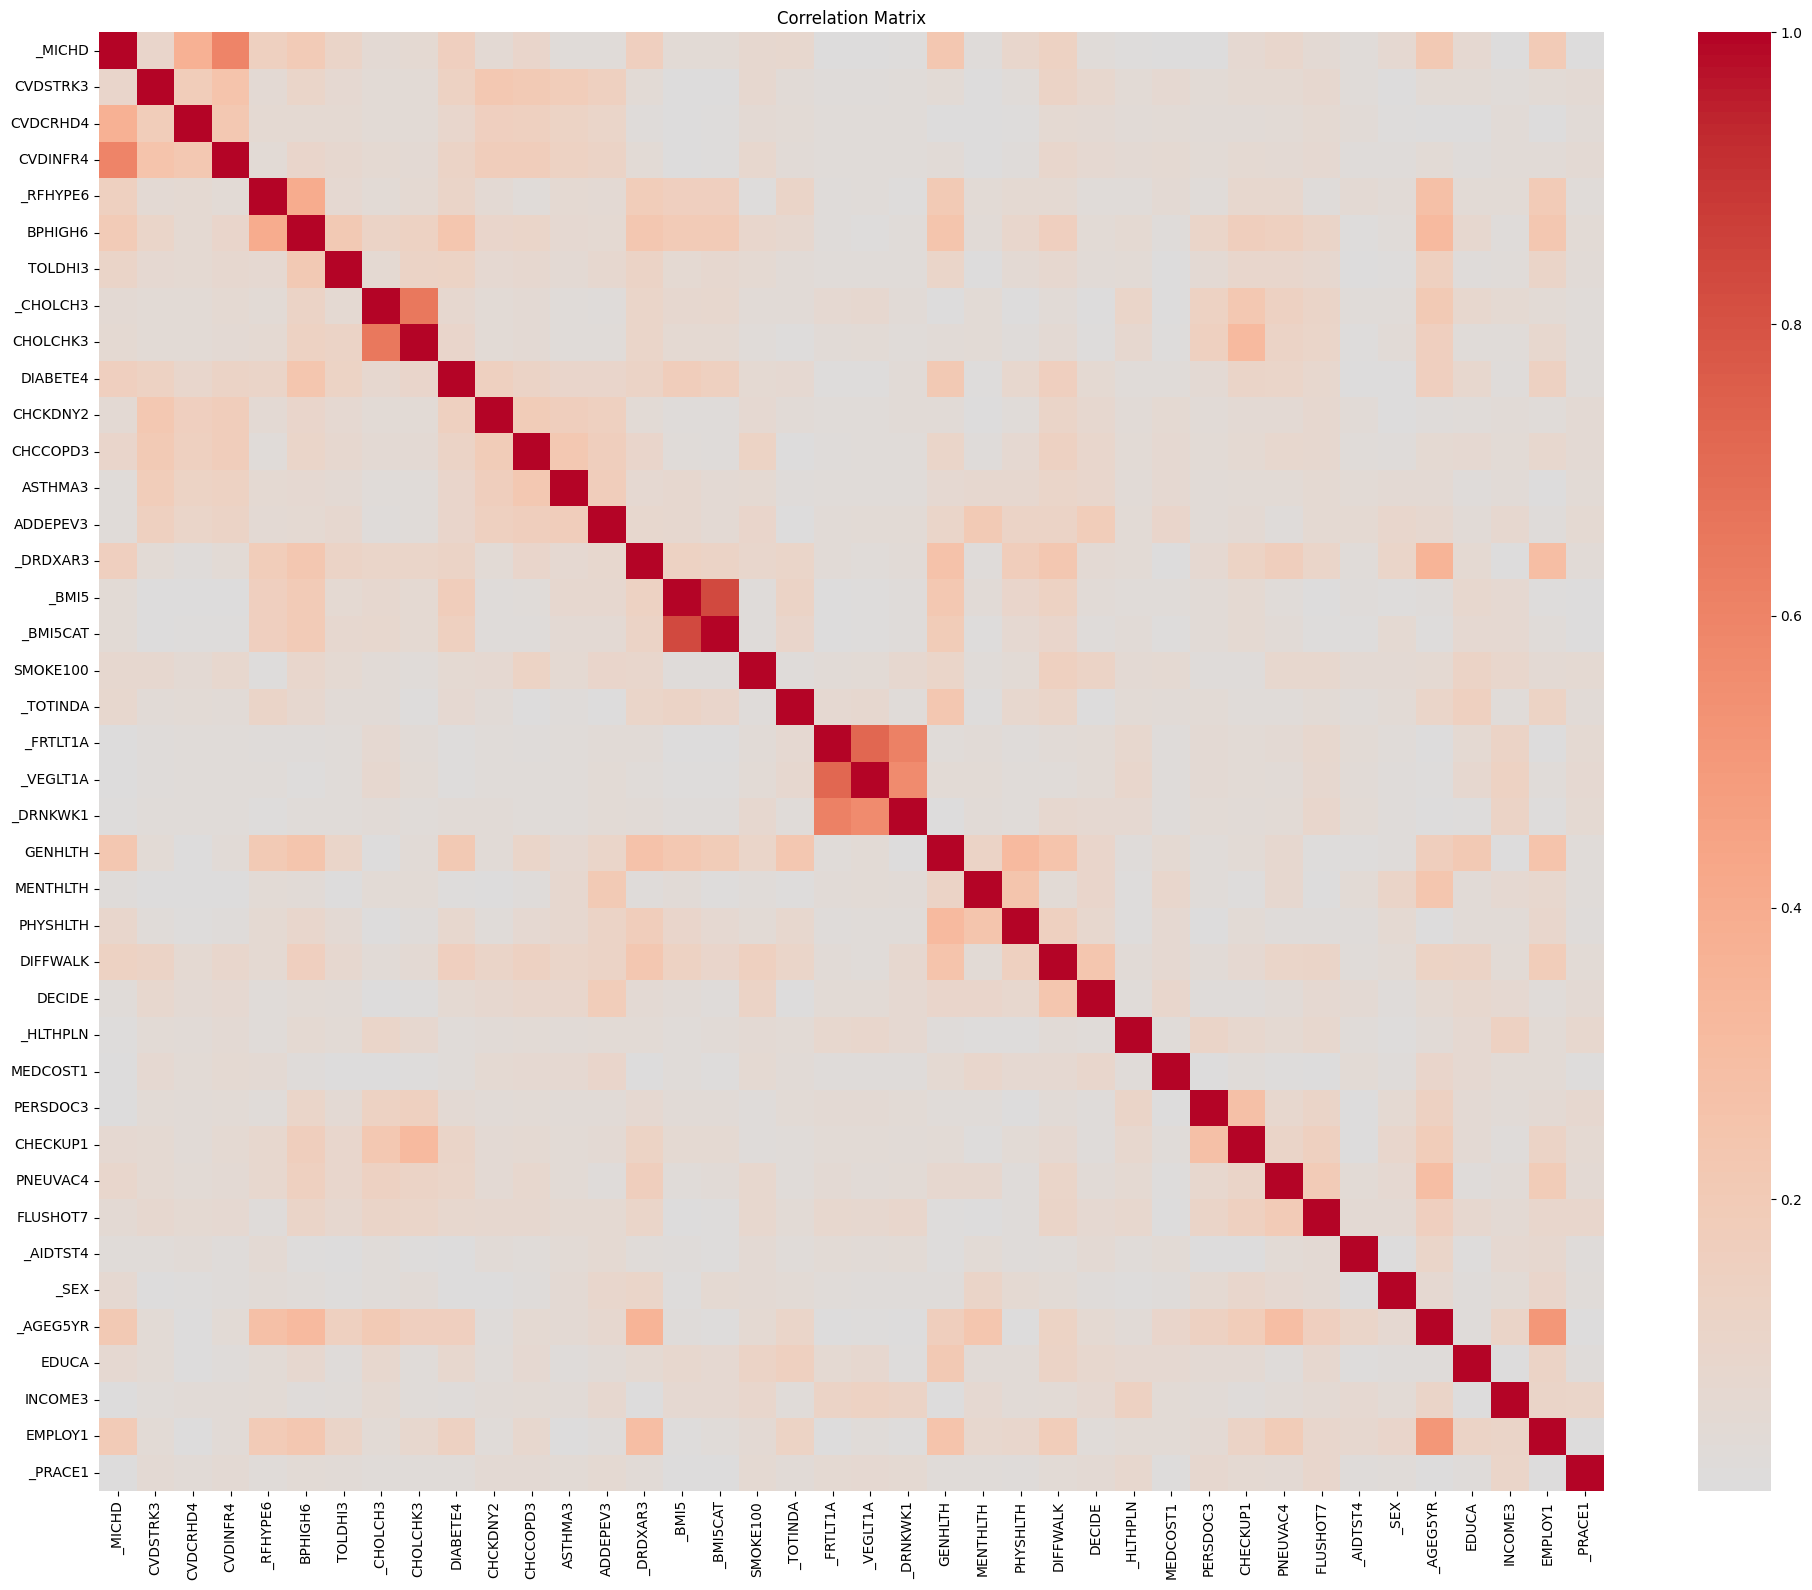

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi
corr_matrix = data_final.select_dtypes(include='float64').corr().abs()

# Visualisasi heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm',
            center=0,
            annot=False,  # ganti True kalau mau lihat angkanya (lambat kalau banyak fitur)
            fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [6]:
# Tampilkan pasangan fitur dengan korelasi > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper.loc[row, col]) 
             for col in upper.columns 
             for row in upper.index 
             if upper.loc[row, col] > 0.50]

high_corr_df = pd.DataFrame(high_corr, columns=['Fitur_1', 'Fitur_2', 'Korelasi'])
high_corr_df = high_corr_df.sort_values('Korelasi', ascending=False)

print(f"Pasangan fitur dengan korelasi > 0.85: {len(high_corr_df)}")
print(high_corr_df.to_string(index=False))

Pasangan fitur dengan korelasi > 0.85: 7
 Fitur_1  Fitur_2  Korelasi
_BMI5CAT    _BMI5  0.830420
_VEGLT1A _FRTLT1A  0.721476
CHOLCHK3 _CHOLCH3  0.648654
_DRNKWK1 _FRTLT1A  0.609881
CVDINFR4   _MICHD  0.600431
_DRNKWK1 _VEGLT1A  0.569375
 EMPLOY1 _AGEG5YR  0.511347


In [7]:
data_final = data_final.drop(columns=['_BMI5CAT'])

In [8]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data_final.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data_final[col].value_counts(dropna=False))


Kolom: CVD_LABEL
CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

Kolom: _MICHD
_MICHD
2.0    398735
1.0     35323
NaN      4635
Name: count, dtype: int64

Kolom: CVDSTRK3
CVDSTRK3
2.0    420051
1.0     17213
7.0      1130
9.0       297
NaN         2
Name: count, dtype: int64

Kolom: CVDCRHD4
CVDCRHD4
2.0    411527
1.0     22891
7.0      3934
9.0       339
NaN         2
Name: count, dtype: int64

Kolom: CVDINFR4
CVDINFR4
2.0    413207
1.0     22831
7.0      2319
9.0       334
NaN         2
Name: count, dtype: int64

Kolom: _RFHYPE6
_RFHYPE6
1.0    264648
2.0    172133
9.0      1912
Name: count, dtype: int64

Kolom: BPHIGH6
BPHIGH6
3.0    256603
1.0    172133
4.0      4571
2.0      3474
7.0      1191
9.0       719
NaN         2
Name: count, dtype: int64

Kolom: TOLDHI3
TOLDHI3


In [9]:
import pandas as pd
import numpy as np

# Nilai yang perlu diganti NaN per variabel
nan_map = {
    'CVDSTRK3':  [7.0, 9.0],
    'CVDCRHD4':  [7.0, 9.0],
    'CVDINFR4':  [7.0, 9.0],
    'BPHIGH6':   [7.0, 9.0],
    'TOLDHI3':   [7.0, 9.0],
    '_CHOLCH3':  [9.0],
    'CHOLCHK3':  [7.0, 9.0],
    'DIABETE4':  [7.0, 9.0],
    'CHCKDNY2':  [7.0, 9.0],
    'CHCCOPD3':  [7.0, 9.0],
    'ASTHMA3':   [7.0, 9.0],
    'ADDEPEV3':  [7.0, 9.0],
    '_DRDXAR3':  [],           # sudah NaN semua
    'SMOKE100':  [7.0, 9.0],
    '_TOTINDA':  [9.0],
    '_FRTLT1A':  [9.0],
    '_VEGLT1A':  [9.0],
    'GENHLTH':   [7.0, 9.0],
    'MENTHLTH':  [77.0, 99.0],
    'PHYSHLTH':  [77.0, 99.0],
    'DIFFWALK':  [7.0, 9.0],
    'DECIDE':    [7.0, 9.0],
    '_HLTHPLN':  [9.0],
    'MEDCOST1':  [7.0, 9.0],
    'PERSDOC3':  [7.0, 9.0],
    'CHECKUP1':  [7.0, 8.0, 9.0],
    'PNEUVAC4':  [7.0, 9.0],
    'FLUSHOT7':  [7.0, 9.0],
    '_AIDTST4':  [9.0],
    'EDUCA':     [9.0],
    'INCOME3':   [77.0, 99.0],
    'EMPLOY1':   [9.0],
    '_PRACE1':   [77.0, 99.0],
}

for col, invalid_vals in nan_map.items():
    if col in data_final.columns and invalid_vals:
        data_final[col] = data_final[col].replace(invalid_vals, np.nan)

print("Selesai! Cek missing values:")
print(data_final[nan_map.keys()].isna().sum())

Selesai! Cek missing values:
CVDSTRK3     1429
CVDCRHD4     4275
CVDINFR4     2655
BPHIGH6      1912
TOLDHI3     63980
_CHOLCH3    29782
CHOLCHK3    29782
DIABETE4      985
CHCKDNY2     1813
CHCCOPD3     2107
ASTHMA3      1746
ADDEPEV3     2517
_DRDXAR3     2896
SMOKE100    24461
_TOTINDA      928
_FRTLT1A    51087
_VEGLT1A    60127
GENHLTH      1161
MENTHLTH     7917
PHYSHLTH     9494
DIFFWALK    19830
DECIDE      19980
_HLTHPLN    17397
MEDCOST1     1364
PERSDOC3     3705
CHECKUP1     8216
PNEUVAC4    62801
FLUSHOT7    31392
_AIDTST4    51856
EDUCA        2478
INCOME3     94413
EMPLOY1      8251
_PRACE1     13363
dtype: int64


In [10]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Data columns (total 40 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CVD_LABEL  438693 non-null  object 
 1   _MICHD     434058 non-null  float64
 2   CVDSTRK3   437264 non-null  float64
 3   CVDCRHD4   434418 non-null  float64
 4   CVDINFR4   436038 non-null  float64
 5   _RFHYPE6   438693 non-null  float64
 6   BPHIGH6    436781 non-null  float64
 7   TOLDHI3    374713 non-null  float64
 8   _CHOLCH3   408911 non-null  float64
 9   CHOLCHK3   408911 non-null  float64
 10  DIABETE4   437708 non-null  float64
 11  CHCKDNY2   436880 non-null  float64
 12  CHCCOPD3   436586 non-null  float64
 13  ASTHMA3    436947 non-null  float64
 14  ADDEPEV3   436176 non-null  float64
 15  _DRDXAR3   435797 non-null  float64
 16  _BMI5      391841 non-null  float64
 17  SMOKE100   414232 non-null  float64
 18  _TOTINDA   437765 non-null  float64
 19  _FRTLT1A   387606 non-n

In [11]:
data_final.describe()

,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
count,434058.000000,437264.000000,434418.000000,436038.000000,438693.000000,436781.000000,374713.000000,408911.000000,408911.000000,437708.000000,...,430477.000000,375892.000000,407301.000000,386837.000000,438693.000000,438693.000000,436215.000000,344280.000000,430442.000000,425330.000000
mean,1.918621,1.960635,1.947307,1.947640,1.427244,2.214323,1.600430,1.186539,2.405142,2.750752,...,1.356802,1.596778,1.479098,1.666506,1.535529,7.726016,5.012790,6.698330,3.747225,1.431935
std,0.273416,0.194463,0.223421,0.222752,0.699127,0.988691,0.489811,0.552422,1.300781,0.704141,...,0.772044,0.490545,0.499564,0.471462,0.498737,3.645926,1.007272,2.422855,2.837228,1.143380
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,5.000000,1.000000,1.000000
50%,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,1.000000,2.000000,2.000000,8.000000,5.000000,7.000000,2.000000,1.000000
75%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,1.000000,2.000000,3.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,11.000000,6.000000,9.000000,7.000000,1.000000
max,2.000000,2.000000,2.000000,2.000000,9.000000,4.000000,2.000000,3.000000,8.000000,4.000000,...,4.000000,2.000000,2.000000,2.000000,2.000000,14.000000,6.000000,11.000000,8.000000,8.000000


In [12]:
data_final.isna().sum()

CVD_LABEL        0
_MICHD        4635
CVDSTRK3      1429
CVDCRHD4      4275
CVDINFR4      2655
_RFHYPE6         0
BPHIGH6       1912
TOLDHI3      63980
_CHOLCH3     29782
CHOLCHK3     29782
DIABETE4       985
CHCKDNY2      1813
CHCCOPD3      2107
ASTHMA3       1746
ADDEPEV3      2517
_DRDXAR3      2896
_BMI5        46852
SMOKE100     24461
_TOTINDA       928
_FRTLT1A     51087
_VEGLT1A     60127
_DRNKWK1         0
GENHLTH       1161
MENTHLTH      7917
PHYSHLTH      9494
DIFFWALK     19830
DECIDE       19980
_HLTHPLN     17397
MEDCOST1      1364
PERSDOC3      3705
CHECKUP1      8216
PNEUVAC4     62801
FLUSHOT7     31392
_AIDTST4     51856
_SEX             0
_AGEG5YR         0
EDUCA         2478
INCOME3      94413
EMPLOY1       8251
_PRACE1      13363
dtype: int64

In [13]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data_final['CVD_SEVERITY'] = data_final['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data_final['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [14]:
data_final.isnull().sum()

CVD_LABEL           0
_MICHD           4635
CVDSTRK3         1429
CVDCRHD4         4275
CVDINFR4         2655
_RFHYPE6            0
BPHIGH6          1912
TOLDHI3         63980
_CHOLCH3        29782
CHOLCHK3        29782
DIABETE4          985
CHCKDNY2         1813
CHCCOPD3         2107
ASTHMA3          1746
ADDEPEV3         2517
_DRDXAR3         2896
_BMI5           46852
SMOKE100        24461
_TOTINDA          928
_FRTLT1A        51087
_VEGLT1A        60127
_DRNKWK1            0
GENHLTH          1161
MENTHLTH         7917
PHYSHLTH         9494
DIFFWALK        19830
DECIDE          19980
_HLTHPLN        17397
MEDCOST1         1364
PERSDOC3         3705
CHECKUP1         8216
PNEUVAC4        62801
FLUSHOT7        31392
_AIDTST4        51856
_SEX                0
_AGEG5YR            0
EDUCA            2478
INCOME3         94413
EMPLOY1          8251
_PRACE1         13363
CVD_SEVERITY        0
dtype: int64

In [15]:
data_final

,CVD_LABEL,_MICHD,CVDSTRK3,CVDCRHD4,CVDINFR4,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,...,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1,CVD_SEVERITY
0,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0,0
1,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0,1
2,CHD Only,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0,1
3,Healt,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,2.0,...,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0,0
4,MI + Stroke,1.0,1.0,NaN,1.0,1.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,6.0,...,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN,0
438689,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0,0
438690,Healt,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,...,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0,0
438691,Healt,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN,0


In [16]:
data_final = data_final.drop(columns=['CVD_SEVERITY','CVD_LABEL','CVDINFR4','CVDCRHD4'])
data_final

,_MICHD,CVDSTRK3,_RFHYPE6,BPHIGH6,TOLDHI3,_CHOLCH3,CHOLCHK3,DIABETE4,CHCKDNY2,CHCCOPD3,...,CHECKUP1,PNEUVAC4,FLUSHOT7,_AIDTST4,_SEX,_AGEG5YR,EDUCA,INCOME3,EMPLOY1,_PRACE1
0,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,2.0,1.0,1.0,2.0,2.0,11.0,4.0,5.0,7.0,1.0
1,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,10.0,6.0,NaN,8.0,2.0
2,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,11.0,4.0,3.0,7.0,2.0
3,2.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,9.0,4.0,7.0,7.0,1.0
4,1.0,1.0,1.0,4.0,1.0,1.0,2.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,12.0,3.0,4.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,1.0,...,4.0,1.0,2.0,1.0,2.0,3.0,4.0,5.0,1.0,NaN
438689,2.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,13.0,4.0,1.0,8.0,6.0
438690,2.0,2.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,7.0,6.0,10.0,7.0,2.0
438691,2.0,2.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,...,1.0,2.0,2.0,1.0,1.0,10.0,4.0,6.0,7.0,NaN


In [17]:
data_new = data_final.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 206064 baris
Terhapus: 232629 baris


In [18]:
data_new['_MICHD'].value_counts()

_MICHD
2.0    188015
1.0     18049
Name: count, dtype: int64

In [19]:
severity_map = {
    2.0       : 0,  # Sehat
    1.0       : 1,  # Level 1 → 1 kondisi
}
data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)

# Verifikasi
print(data_new['_MICHD'].value_counts())
print(f"\nTotal : {len(data1):,}")

_MICHD
0    188015
1     18049
Name: count, dtype: int64

Total : 438,693


/var/folders/c1/0skxdwdx0zdcpl8hlxr2xcz40000gn/T/ipykernel_2301/2707975189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['_MICHD'] = data_new['_MICHD'].map(severity_map)


In [20]:
data_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206064 entries, 0 to 438692
Data columns (total 37 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _MICHD    206064 non-null  int64  
 1   CVDSTRK3  206064 non-null  float64
 2   _RFHYPE6  206064 non-null  float64
 3   BPHIGH6   206064 non-null  float64
 4   TOLDHI3   206064 non-null  float64
 5   _CHOLCH3  206064 non-null  float64
 6   CHOLCHK3  206064 non-null  float64
 7   DIABETE4  206064 non-null  float64
 8   CHCKDNY2  206064 non-null  float64
 9   CHCCOPD3  206064 non-null  float64
 10  ASTHMA3   206064 non-null  float64
 11  ADDEPEV3  206064 non-null  float64
 12  _DRDXAR3  206064 non-null  float64
 13  _BMI5     206064 non-null  float64
 14  SMOKE100  206064 non-null  float64
 15  _TOTINDA  206064 non-null  float64
 16  _FRTLT1A  206064 non-null  float64
 17  _VEGLT1A  206064 non-null  float64
 18  _DRNKWK1  206064 non-null  float64
 19  GENHLTH   206064 non-null  float64
 20  MENTHLTH 

In [21]:
X = data_new.drop(columns=['_MICHD'])
y = data_new['_MICHD']

### Training Model

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164851 entries, 4662 to 39906
Data columns (total 36 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   CVDSTRK3  164851 non-null  float64
 1   _RFHYPE6  164851 non-null  float64
 2   BPHIGH6   164851 non-null  float64
 3   TOLDHI3   164851 non-null  float64
 4   _CHOLCH3  164851 non-null  float64
 5   CHOLCHK3  164851 non-null  float64
 6   DIABETE4  164851 non-null  float64
 7   CHCKDNY2  164851 non-null  float64
 8   CHCCOPD3  164851 non-null  float64
 9   ASTHMA3   164851 non-null  float64
 10  ADDEPEV3  164851 non-null  float64
 11  _DRDXAR3  164851 non-null  float64
 12  _BMI5     164851 non-null  float64
 13  SMOKE100  164851 non-null  float64
 14  _TOTINDA  164851 non-null  float64
 15  _FRTLT1A  164851 non-null  float64
 16  _VEGLT1A  164851 non-null  float64
 17  _DRNKWK1  164851 non-null  float64
 18  GENHLTH   164851 non-null  float64
 19  MENTHLTH  164851 non-null  float64
 20  PHYSHLT

In [24]:
# %%
# =============================================================
# FUNCTION: RESAMPLE + SCALE + TRAIN + EVALUATE
# =============================================================
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def resample_scale_train(
    X_train, X_test, y_train, y_test,
    resample_method = 'smote',       # Pilihan resampling
    scaler_type     = 'minmax',      # Pilihan scaler
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.1,
    label_names     = ('Sehat', 'CVD')
):
    """
    Pipeline lengkap: Resampling → Scaling → Training → Evaluasi XGBoost.

    Parameters
    ----------
    X_train, X_test   : DataFrame  — fitur train/test
    y_train, y_test   : Series     — label train/test (binary 0/1)
    resample_method   : str        — 'smote' | 'adasyn' | 'ros' | 'rus' |
                                     'tomek' | 'enn' | 'smotetomek' | 'smoteenn' | None
    scaler_type       : str        — 'minmax' | 'standard' | 'robust' | None
    n_estimators      : int        — jumlah pohon XGBoost
    max_depth         : int        — kedalaman pohon XGBoost
    learning_rate     : float      — learning rate XGBoost
    label_names       : tuple      — nama kelas (default: Sehat, CVD)

    Returns
    -------
    dict — model, metrics, data hasil resampling & scaling
    """

    # ── STEP 1: RESAMPLING ────────────────────────────────────────────────────
    resamplers = {
        'smote'     : SMOTE(random_state=42, k_neighbors=5),
        'adasyn'    : ADASYN(random_state=42),
        'ros'       : RandomOverSampler(random_state=42),
        'rus'       : RandomUnderSampler(random_state=42),
        'tomek'     : TomekLinks(),
        'enn'       : EditedNearestNeighbours(),
        'smotetomek': SMOTETomek(random_state=42),
        'smoteenn'  : SMOTEENN(random_state=42),
    }

    print("=" * 55)
    print(f"  STEP 1 — RESAMPLING  ({resample_method or 'None / Skip'})")
    print("=" * 55)
    print(f"  Sebelum : {Counter(y_train)}")

    if resample_method and resample_method in resamplers:
        resampler = resamplers[resample_method]
        X_train_res, y_train_res = resampler.fit_resample(X_train, y_train)
        X_train_res = pd.DataFrame(X_train_res, columns=X_train.columns)
        y_train_res = pd.Series(y_train_res, name=y_train.name)
    else:
        X_train_res, y_train_res = X_train.copy(), y_train.copy()
        if resample_method:
            print(f"  ⚠️  Metode '{resample_method}' tidak dikenal, resampling dilewati.")

    print(f"  Sesudah : {Counter(y_train_res)}")
    print(f"  Shape   : {X_train.shape} → {X_train_res.shape}\n")

    # ── STEP 2: SCALING ───────────────────────────────────────────────────────
    scalers = {
        'minmax'  : MinMaxScaler(),
        'standard': StandardScaler(),
        'robust'  : RobustScaler(),
    }

    print("=" * 55)
    print(f"  STEP 2 — SCALING  ({scaler_type or 'None / Skip'})")
    print("=" * 55)

    feature_names = X_train_res.columns.tolist()

    if scaler_type and scaler_type in scalers:
        scaler = scalers[scaler_type]
        X_train_final = pd.DataFrame(
            scaler.fit_transform(X_train_res), columns=feature_names
        )
        X_test_final = pd.DataFrame(
            scaler.transform(X_test), columns=feature_names
        )
        print(f"  Scaler  : {scaler.__class__.__name__}")
    else:
        X_train_final, X_test_final = X_train_res.copy(), X_test.copy()
        if scaler_type:
            print(f"  ⚠️  Scaler '{scaler_type}' tidak dikenal, scaling dilewati.")
        else:
            print("  Scaling dilewati.")

    print(f"  Train shape : {X_train_final.shape}")
    print(f"  Test shape  : {X_test_final.shape}\n")

    # ── STEP 3: TRAINING ──────────────────────────────────────────────────────
    print("=" * 55)
    print("  STEP 3 — TRAINING XGBoost")
    print("=" * 55)

    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)

    model = XGBClassifier(
        n_estimators  = n_estimators,
        max_depth     = max_depth,
        learning_rate = learning_rate,
        eval_metric   = 'logloss',
        random_state  = 42
    )
    model.fit(X_train_final, y_train_res, sample_weight=sample_weights)
    print("  Training selesai.\n")

    # ── STEP 4: EVALUASI ──────────────────────────────────────────────────────
    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    balanced_acc     = balanced_accuracy_score(y_test, y_pred)
    macro_recall     = recall_score(y_test, y_pred, average='macro')
    auc_roc          = roc_auc_score(y_test, y_prob)
    f1_macro         = f1_score(y_test, y_pred, average='macro')
    f1_weighted      = f1_score(y_test, y_pred, average='weighted')
    f1_positive      = f1_score(y_test, y_pred, pos_label=1)
    recall_per_class = recall_score(y_test, y_pred, average=None)
    sensitivity      = recall_per_class[1]
    specificity      = recall_per_class[0]
    cm               = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp   = cm.ravel()

    print("=" * 55)
    print("  STEP 4 — PERFORMANCE MEASURES")
    print("=" * 55)
    print(f"  Balanced Accuracy  : {balanced_acc:.4f}  ← METRIC UTAMA")
    print(f"  Macro-Recall       : {macro_recall:.4f}  ← METRIC UTAMA")
    print(f"  AUC-ROC            : {auc_roc:.4f}")
    print("-" * 55)
    print(f"  F1-Score Macro     : {f1_macro:.4f}")
    print(f"  F1-Score Weighted  : {f1_weighted:.4f}")
    print(f"  F1-Score {label_names[1]:<8}  : {f1_positive:.4f}")
    print("-" * 55)
    print(f"  Sensitivity ({label_names[1]:<5}) : {sensitivity:.4f}")
    print(f"  Specificity ({label_names[0]:<5}) : {specificity:.4f}")
    print("=" * 55)
    print(f"\n  TP:{tp} | TN:{tn} | FP:{fp} ← False Alarm | FN:{fn} ← Berbahaya!")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=[f'{label_names[0]} (0)',
                                              f'{label_names[1]} (1)']))

    # ── STEP 5: PLOT ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Confusion Matrix
    ConfusionMatrixDisplay(cm, display_labels=list(label_names)).plot(
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(
        f"Confusion Matrix — XGBoost\n"
        f"Resample: {resample_method} | Scaler: {scaler_type}\n"
        f"BA: {balanced_acc:.4f} | Recall: {macro_recall:.4f} | AUC: {auc_roc:.4f}"
    )

    # Feature Importance
    importance_df = pd.DataFrame({
        'fitur'     : X_train_final.columns.tolist(),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top20 = importance_df.head(20).sort_values('importance')
    bars  = axes[1].barh(top20['fitur'], top20['importance'], color='steelblue')
    for bar, val in zip(bars, top20['importance']):
        axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                     f'{val:.4f}', va='center', fontsize=8)
    axes[1].set_xlabel('Importance Score')
    axes[1].set_title('Top 20 Feature Importance — XGBoost')

    plt.tight_layout()
    plt.show()

    # ── RETURN ────────────────────────────────────────────────────────────────
    return {
        'model'            : model,
        'scaler'           : scaler if (scaler_type and scaler_type in scalers) else None,
        'balanced_accuracy': balanced_acc,
        'macro_recall'     : macro_recall,
        'auc_roc'          : auc_roc,
        'f1_macro'         : f1_macro,
        'f1_weighted'      : f1_weighted,
        'f1_positive'      : f1_positive,
        'sensitivity'      : sensitivity,
        'specificity'      : specificity,
        'confusion_matrix' : cm,
        'y_pred'           : y_pred,
        'y_prob'           : y_prob,
        'importance_df'    : importance_df,
        'X_train_final'    : X_train_final,
        'X_test_final'     : X_test_final,
        'y_train_res'      : y_train_res,
    }

  STEP 1 — RESAMPLING  (smote)
  Sebelum : Counter({0: 150412, 1: 14439})
  Sesudah : Counter({0: 150412, 1: 150412})
  Shape   : (164851, 36) → (300824, 36)

  STEP 2 — SCALING  (minmax)
  Scaler  : MinMaxScaler
  Train shape : (300824, 36)
  Test shape  : (41213, 36)

  STEP 3 — TRAINING XGBoost
  Training selesai.

  STEP 4 — PERFORMANCE MEASURES
  Balanced Accuracy  : 0.5525  ← METRIC UTAMA
  Macro-Recall       : 0.5525  ← METRIC UTAMA
  AUC-ROC            : 0.8448
-------------------------------------------------------
  F1-Score Macro     : 0.5718
  F1-Score Weighted  : 0.8877
  F1-Score CVD       : 0.1888
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.1139
  Specificity (Sehat) : 0.9912

  TP:411 | TN:37271 | FP:332 ← False Alarm | FN:3199 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.92      0.99      0.95     37603
     CVD (1)       0.55      0.11      0.19      3610

    acc

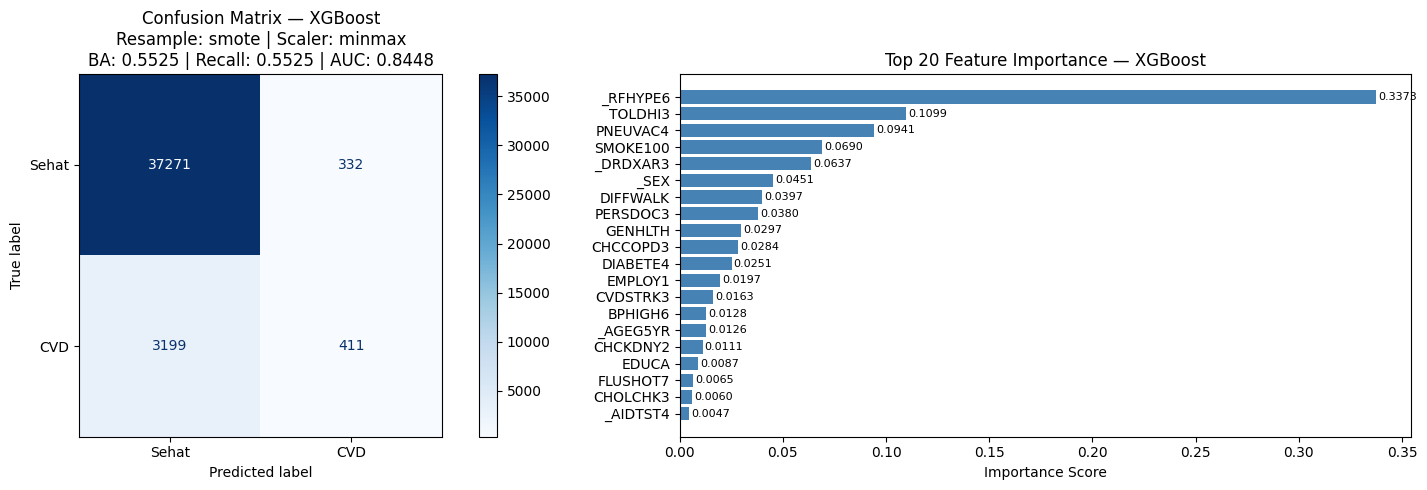

In [25]:
# =============================================================
# CARA PAKAI
# =============================================================

# Default: SMOTE + MinMax
results = resample_scale_train(X_train, X_test, y_train, y_test)


  STEP 1 — RESAMPLING  (None / Skip)
  Sebelum : Counter({0: 150412, 1: 14439})
  Sesudah : Counter({0: 150412, 1: 14439})
  Shape   : (164851, 36) → (164851, 36)

  STEP 2 — SCALING  (minmax)
  Scaler  : MinMaxScaler
  Train shape : (164851, 36)
  Test shape  : (41213, 36)

  STEP 3 — TRAINING XGBoost
  Training selesai.

  STEP 4 — PERFORMANCE MEASURES
  Balanced Accuracy  : 0.7552  ← METRIC UTAMA
  Macro-Recall       : 0.7552  ← METRIC UTAMA
  AUC-ROC            : 0.8384
-------------------------------------------------------
  F1-Score Macro     : 0.6082
  F1-Score Weighted  : 0.8144
  F1-Score CVD       : 0.3582
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7402
  Specificity (Sehat) : 0.7703

  TP:2672 | TN:28966 | FP:8637 ← False Alarm | FN:938 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.97      0.77      0.86     37603
     CVD (1)       0.24      0.74      0.36      3610

 

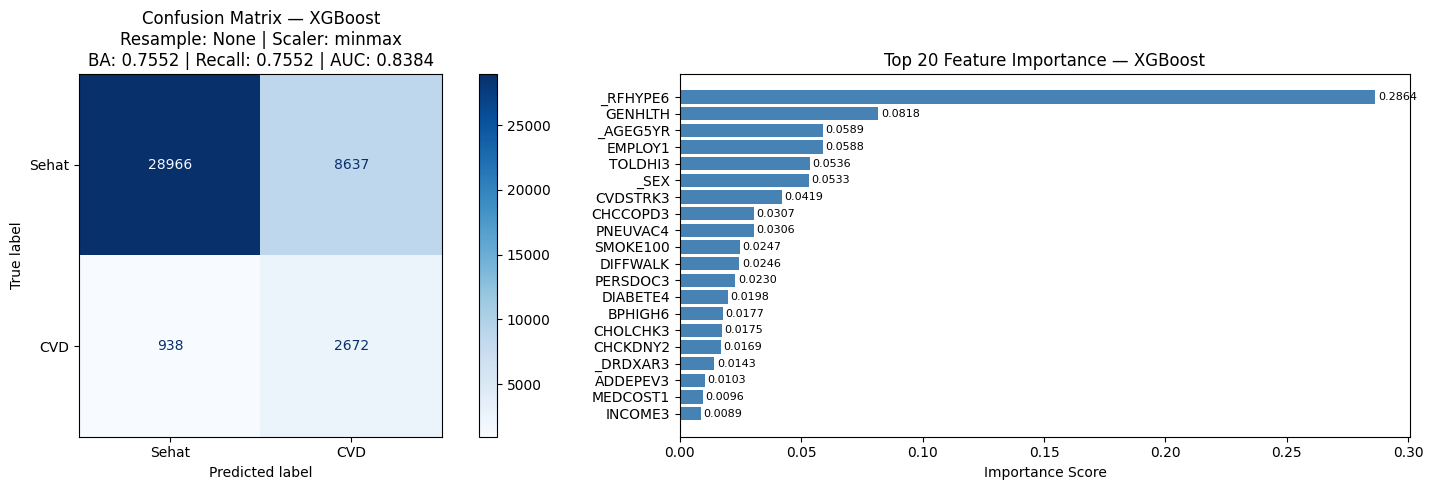

In [26]:
# Ganti metode resampling & scaler
results = resample_scale_train(
    X_train, X_test, y_train, y_test,
    resample_method = None,  # 'smote' | 'adasyn' | 'ros' | 'rus' |
                                     # 'tomek' | 'enn' | 'smotetomek' | 'smoteenn' | None
    scaler_type     = 'minmax',    # 'minmax' | 'standard' | 'robust' | None
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.1,
)

  STEP 1 — RESAMPLING  (tomek)
  Sebelum : Counter({0: 150412, 1: 14439})
  Sesudah : Counter({0: 144590, 1: 14439})
  Shape   : (164851, 36) → (159029, 36)

  STEP 2 — SCALING  (minmax)
  Scaler  : MinMaxScaler
  Train shape : (159029, 36)
  Test shape  : (41213, 36)

  STEP 3 — TRAINING XGBoost
  Training selesai.

  STEP 4 — PERFORMANCE MEASURES
  Balanced Accuracy  : 0.7580  ← METRIC UTAMA
  Macro-Recall       : 0.7580  ← METRIC UTAMA
  AUC-ROC            : 0.8392
-------------------------------------------------------
  F1-Score Macro     : 0.6071
  F1-Score Weighted  : 0.8123
  F1-Score CVD       : 0.3582
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.7499
  Specificity (Sehat) : 0.7661

  TP:2707 | TN:28807 | FP:8796 ← False Alarm | FN:903 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.97      0.77      0.86     37603
     CVD (1)       0.24      0.75      0.36      3610

    acc

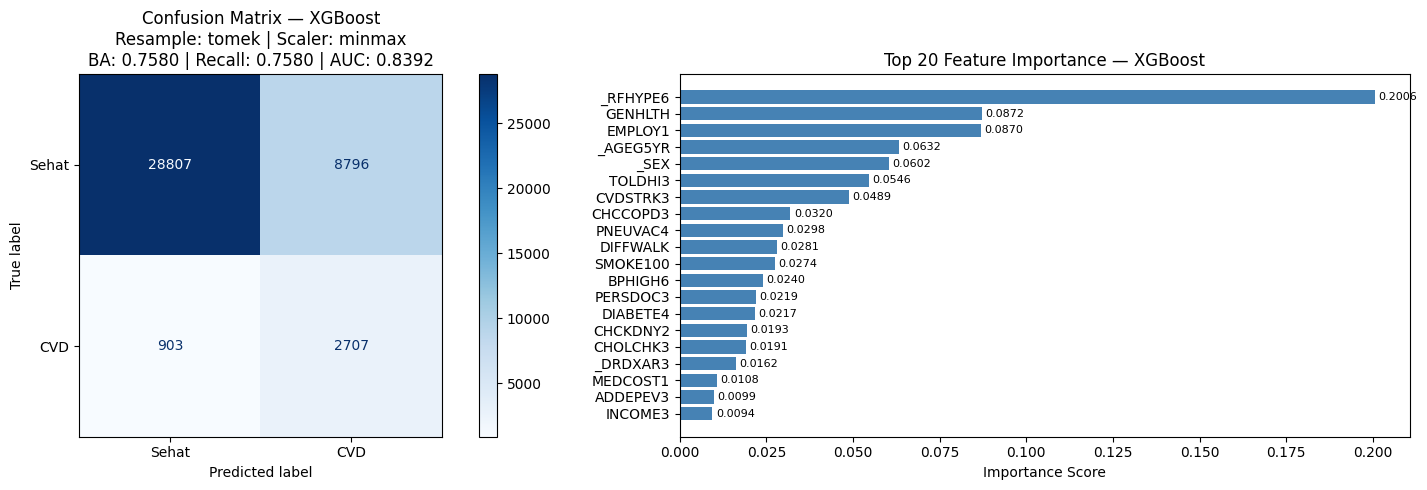

In [28]:
# Ganti metode resampling & scaler
results = resample_scale_train(
    X_train, X_test, y_train, y_test,
    resample_method = 'tomek',  # 'smote' | 'adasyn' | 'ros' | 'rus' |
                                     # 'tomek' | 'enn' | 'smotetomek' | 'smoteenn' | None
    scaler_type     = 'minmax',    # 'minmax' | 'standard' | 'robust' | None
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.1,
)

  STEP 1 — RESAMPLING  (smoteenn)
  Sebelum : Counter({0: 150412, 1: 14439})
  Sesudah : Counter({1: 138193, 0: 98248})
  Shape   : (164851, 36) → (236441, 36)

  STEP 2 — SCALING  (minmax)
  Scaler  : MinMaxScaler
  Train shape : (236441, 36)
  Test shape  : (41213, 36)

  STEP 3 — TRAINING XGBoost
  Training selesai.

  STEP 4 — PERFORMANCE MEASURES
  Balanced Accuracy  : 0.6390  ← METRIC UTAMA
  Macro-Recall       : 0.6390  ← METRIC UTAMA
  AUC-ROC            : 0.8377
-------------------------------------------------------
  F1-Score Macro     : 0.6485
  F1-Score Weighted  : 0.8913
  F1-Score CVD       : 0.3541
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.3288
  Specificity (Sehat) : 0.9493

  TP:1187 | TN:35696 | FP:1907 ← False Alarm | FN:2423 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.94      0.95      0.94     37603
     CVD (1)       0.38      0.33      0.35      3610

   

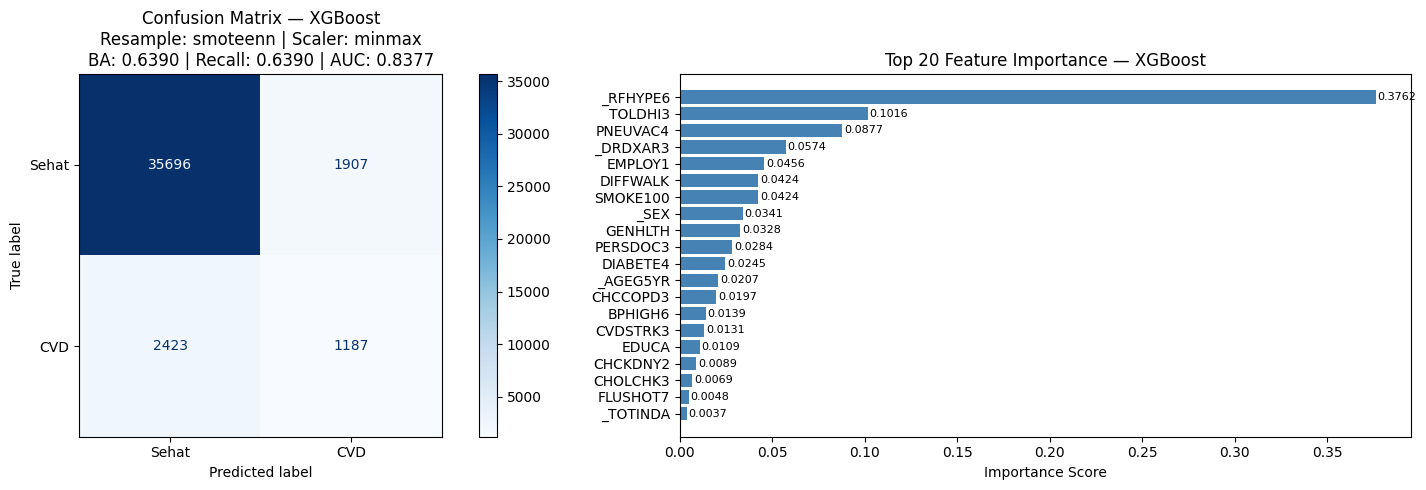

In [29]:
# Ganti metode resampling & scaler
results = resample_scale_train(
    X_train, X_test, y_train, y_test,
    resample_method = 'smoteenn',  # 'smote' | 'adasyn' | 'ros' | 'rus' |
                                     # 'tomek' | 'enn' | 'smotetomek' | 'smoteenn' | None
    scaler_type     = 'minmax',    # 'minmax' | 'standard' | 'robust' | None
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.1,
)

  STEP 1 — RESAMPLING  (smotetomek)
  Sebelum : Counter({0: 150412, 1: 14439})
  Sesudah : Counter({0: 148808, 1: 148808})
  Shape   : (164851, 36) → (297616, 36)

  STEP 2 — SCALING  (minmax)
  Scaler  : MinMaxScaler
  Train shape : (297616, 36)
  Test shape  : (41213, 36)

  STEP 3 — TRAINING XGBoost
  Training selesai.

  STEP 4 — PERFORMANCE MEASURES
  Balanced Accuracy  : 0.5513  ← METRIC UTAMA
  Macro-Recall       : 0.5513  ← METRIC UTAMA
  AUC-ROC            : 0.8453
-------------------------------------------------------
  F1-Score Macro     : 0.5697
  F1-Score Weighted  : 0.8870
  F1-Score CVD       : 0.1851
-------------------------------------------------------
  Sensitivity (CVD  ) : 0.1119
  Specificity (Sehat) : 0.9906

  TP:404 | TN:37251 | FP:352 ← False Alarm | FN:3206 ← Berbahaya!

Classification Report:
              precision    recall  f1-score   support

   Sehat (0)       0.92      0.99      0.95     37603
     CVD (1)       0.53      0.11      0.19      3610

  

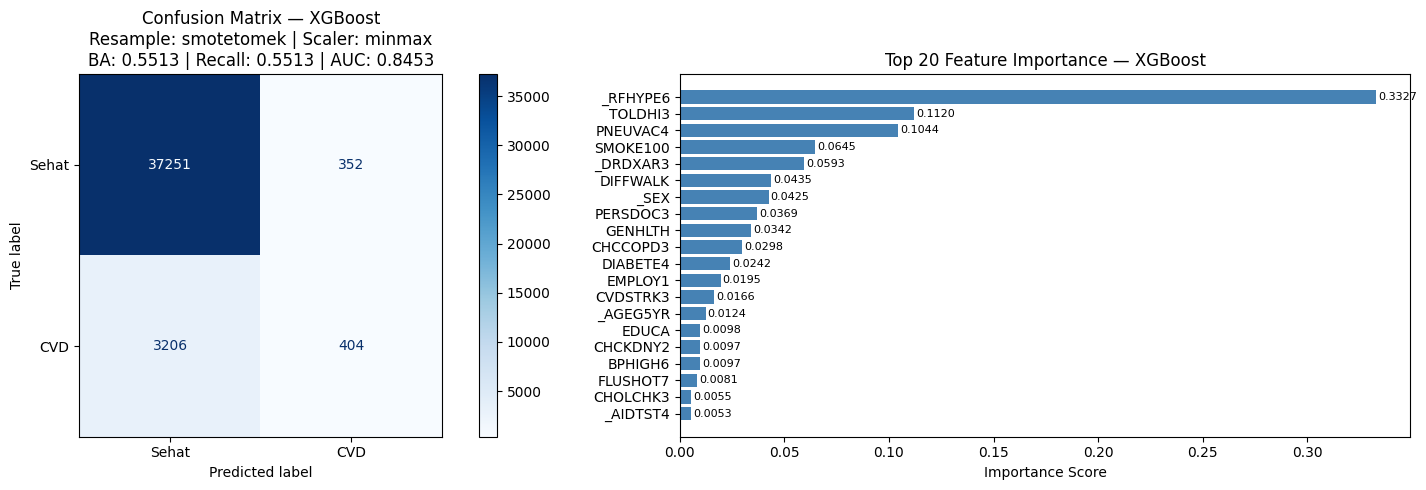

In [30]:
# Ganti metode resampling & scaler
results = resample_scale_train(
    X_train, X_test, y_train, y_test,
    resample_method = 'smotetomek',  # 'smote' | 'adasyn' | 'ros' | 'rus' |
                                     # 'tomek' | 'enn' | 'smotetomek' | 'smoteenn' | None
    scaler_type     = 'minmax',    # 'minmax' | 'standard' | 'robust' | None
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.1,
)